In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set seed agar angka randomnya selalu sama setiap kali dijalankan
np.random.seed(42)

total_rumah = 100
total_bulan = 12

# =====================================================================
# 1. GENERATE DATASET (Ditambah Fitur Baru & Kebisingan Dijinakkan)
# =====================================================================
bulan_names = ['Januari', 'Februari', 'Maret', 'April', 'Mei', 'Juni', 
               'Juli', 'Agustus', 'September', 'Oktober', 'November', 'Desember']
bulan = []
musim = []
for b in bulan_names:
    bulan.extend([b] * total_rumah)
    # Musim: 0=Hujan (Jan-Mar, Oct-Dec), 1=Kemarau (Apr-Sep)
    musim.extend([0] * total_rumah if b in ['Januari', 'Februari', 'Maret', 'Oktober', 'November', 'Desember'] 
                 else [1] * total_rumah)

total_rows = total_rumah * total_bulan

# Generate Fitur Independen Dasar
jml_anggota = np.random.randint(2, 7, size=total_rows) # Acak 2-6 orang
jml_keran = jml_anggota + np.random.randint(1, 4, size=total_rows) # Jml orang + acak 1-3 keran

# --- [UPDATE] TAMBAH FITUR BARU ---
# Ada_Taman: 30% kemungkinan rumah punya taman (0 = tidak, 1 = ya)
ada_taman = np.random.choice([0, 1], size=total_rows, p=[0.7, 0.3])
# Ada_Toko: 15% kemungkinan rumah punya usaha/toko/warung (0 = tidak, 1 = ya)
ada_toko = np.random.choice([0, 1], size=total_rows, p=[0.85, 0.15])

# --- MODIFIKASI LOGIKA NATURAL ---
konsumsi_per_orang = np.random.uniform(4.0, 7.0, size=total_rows)
tambahan_musim = np.array(musim) * np.random.uniform(2.0, 5.0, size=total_rows)

# --- [UPDATE] KEBISINGAN DIJINAKKAN ---
# Rentang noise ekstrem dipersempit dari (-15 s/d 20) menjadi (-3 s/d 3) agar model lebih akurat
noise_jinak = np.random.randint(-3, 4, size=total_rows)

# Hitung Volume Air total dengan melibatkan Fitur Baru & Noise Jinak
# Rumah dengan taman otomatis +6 m3, rumah dengan toko +10 m3
volume_m3 = np.round((jml_anggota * konsumsi_per_orang) + 
                     tambahan_musim + 
                     (ada_taman * 6.0) + 
                     (ada_toko * 10.0) + 
                     noise_jinak)

# Batasi agar tidak ada volume air yang minus (paling sedikit 2 m3)
volume_m3 = np.clip(volume_m3, 2, None)

# Gabungkan semua ke dalam DataFrame (Tabel)
df_simulasi = pd.DataFrame({
    'No_Rumah': list(range(1, total_rumah + 1)) * total_bulan,
    'Bulan': bulan,
    'Musim': musim,
    'Jml_Anggota': jml_anggota,
    'Jml_Keran': jml_keran,
    'Ada_Taman': ada_taman,
    'Ada_Toko': ada_toko,
    'Volume_m3': volume_m3,
})

print(f"--- 1. Dataset Berhasil Dibuat: {len(df_simulasi)} baris ---")
df_simulasi.to_csv('data_tagihan_air_natural.csv', index=False)

--- 1. Dataset Berhasil Dibuat: 1200 baris ---


--- 2. Preprocessing & Splitting Selesai ---
--- 3. Model Linear Regression Selesai Dilatih ---

================ EVALUASI MODEL REALISTIS ================
R-Squared (Akurasi Model)     : 83.08%
Rata-rata Meleset (MAE)       : 3.44 m3
Standar Deviasi Error (RMSE)  : 4.26 m3


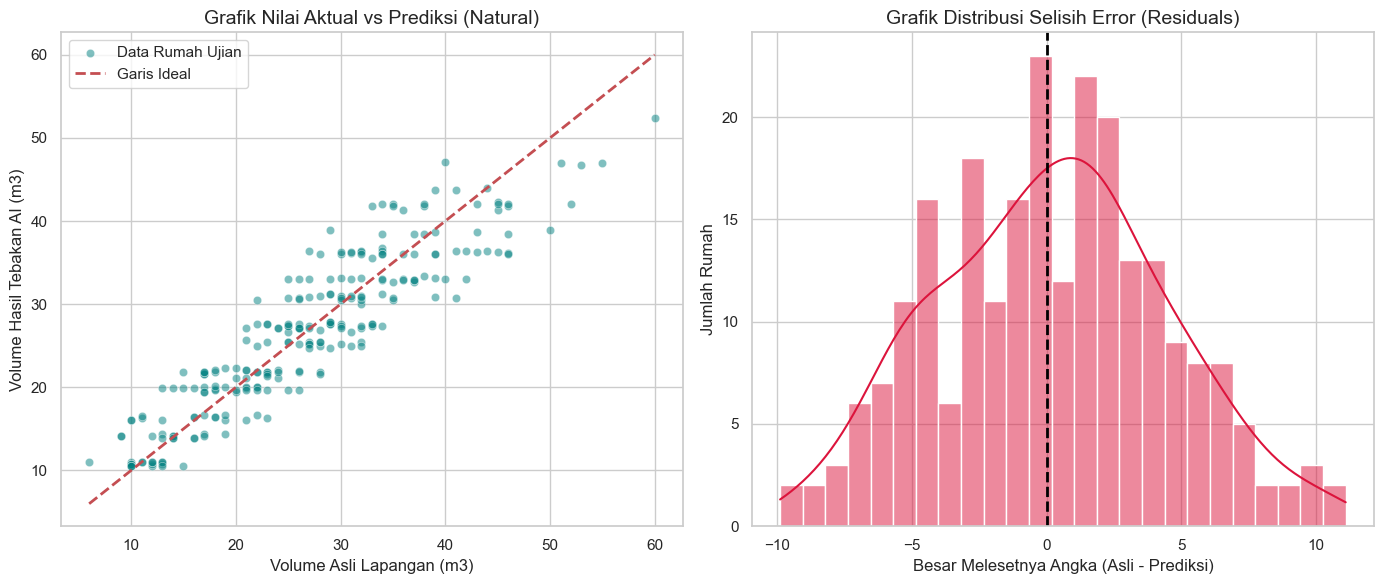

In [2]:
# =====================================================================
# 2. PREPROCESSING DATA
# =====================================================================
# --- [UPDATE] DAFTARKAN FITUR BARU DI VARIABEL X ---
X = df_simulasi[['Musim', 'Jml_Anggota', 'Jml_Keran', 'Ada_Taman', 'Ada_Toko']]
Y = df_simulasi['Volume_m3']

# Bagi data: 80% untuk latihan (Train), 20% untuk ujian (Test)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("--- 2. Preprocessing & Splitting Selesai ---")

# =====================================================================
# 3. TRAINING MODEL (MULTIVARIABLE LINEAR REGRESSION)
# =====================================================================
model = LinearRegression()
model.fit(X_train_scaled, Y_train)

print("--- 3. Model Linear Regression Selesai Dilatih ---")

# =====================================================================
# 4. EVALUASI MODEL
# =====================================================================
Y_pred = model.predict(X_test_scaled)

r2 = r2_score(Y_test, Y_pred)
mae = mean_absolute_error(Y_test, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, Y_pred))

print("\n================ EVALUASI MODEL REALISTIS ================")
print(f"R-Squared (Akurasi Model)     : {r2 * 100:.2f}%")
print(f"Rata-rata Meleset (MAE)       : {mae:.2f} m3")
print(f"Standar Deviasi Error (RMSE)  : {rmse:.2f} m3") # Koreksi tipe typo Rp kemarin
print("==========================================================")

# =====================================================================
# 5. VISUALISASI GRAFIK EVALUASI
# =====================================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Grafik 1: Aktual vs Prediksi
plt.subplot(1, 2, 1)
sns.scatterplot(x=Y_test, y=Y_pred, alpha=0.5, color='teal', label='Data Rumah Ujian')
plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2, label='Garis Ideal')
plt.title('Grafik Nilai Aktual vs Prediksi (Natural)', fontsize=14)
plt.xlabel('Volume Asli Lapangan (m3)', fontsize=12)
plt.ylabel('Volume Hasil Tebakan AI (m3)', fontsize=12)
plt.legend()

# Grafik 2: Distribusi Error
plt.subplot(1, 2, 2)
residuals = Y_test - Y_pred
sns.histplot(residuals, kde=True, color='crimson', bins=25)
plt.axvline(x=0, color='black', linestyle='--', lw=2)
plt.title('Grafik Distribusi Selisih Error (Residuals)', fontsize=14)
plt.xlabel('Besar Melesetnya Angka (Asli - Prediksi)', fontsize=12)
plt.ylabel('Jumlah Rumah', fontsize=12)

plt.tight_layout()
plt.show()

In [6]:
# =====================================================================
# 6. EXPORT MODEL KE FILE HEADER C++ (.h) UNTUK ESP32
# =====================================================================
import m2cgen as m2c

print("\n--- 6. Memulai Proses Konversi Model ke C++ ---")

# RE-TRAINING: Melatih kembali model TANPA scaling khusus untuk ESP32
model_esp32 = LinearRegression()
model_esp32.fit(X_train, Y_train)

# Evaluasi singkat model tanpa scaling
Y_pred_esp32 = model_esp32.predict(X_test)
r2_esp32 = r2_score(Y_test, Y_pred_esp32)
print(f"Catatan: Akurasi Model Unscaled untuk ESP32 adalah {r2_esp32 * 100:.2f}%")

code_cpp = m2c.export_to_c(model_esp32)

# Membungkus kode hasil konversi ke dalam struktur file header (.h) Arduino
file_content = f"""#ifndef MODEL_REGRESI_H
#define MODEL_REGRESI_H

/* * Fungsi otomatis hasil konversi dari Python (m2cgen)
 * * CARA PENGGUNAAN DI ARDUINO IDE:
 * double data_input[5] = {{Musim, Jml_Anggota, Jml_Keran, Ada_Taman, Ada_Toko}};
 * double prediksi = score(data_input);
 * * Urutan indeks array input wajib sama:
 * input[0] = Musim (0 = Hujan, 1 = Kemarau)
 * input[1] = Jml_Anggota
 * input[2] = Jml_Keran
 * input[3] = Ada_Taman (0 = Tidak, 1 = Ya)
 * input[4] = Ada_Toko  (0 = Tidak, 1 = Ya)
 */

{code_cpp}

#endif // MODEL_REGRESI_H
"""

nama_file_h = 'model_regresi.h'
with open(nama_file_h, 'w') as f:
    f.write(file_content)

print(f"🎉 BERHASIL! File '{nama_file_h}' siap digunakan di ESP32 Anda.")


--- 6. Memulai Proses Konversi Model ke C++ ---
Catatan: Akurasi Model Unscaled untuk ESP32 adalah 83.08%
🎉 BERHASIL! File 'model_regresi.h' siap digunakan di ESP32 Anda.


In [5]:

import os


print("Original Model Size (MB):", os.path.getsize("model_regresi.h") / 1e6)

Original Model Size (MB): 0.000807
